## Import thư viện

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.preprocessing import LabelEncoder

## Đọc dữ liệu từ file CSV

In [28]:

df = pd.read_csv(r"D:\UNIVERSITY\ĐACN\BI-Dashboard-Project\data\live\sales_dashboard.csv")

df.head()

,order_id,order_purchase_timestamp,price,freight_value,payment_value,order_status,seller_id,customer_unique_id,customer_city,customer_state,product_category_name,Category_VN,product_id
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,29.99,8.72,38.71,delivered,3504c0cb71d7fa48d967e0e4c94d59d9,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,utilidades_domesticas,Đồ gia dụng,87285b34884572647811a353c7ac498a
1,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18 19:28:06,45.00,27.20,72.20,delivered,66922902710d126a0e7d26b0e3805106,7c142cf63193a1473d2e66489a9ae977,sao goncalo do amarante,RN,pet_shop,Thú cưng,d0b61bfb1de832b15ba9d266ca96e5b0
2,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 21:18:39,19.90,8.72,28.62,delivered,2c9e548be18521d1c43cde1c582c6de8,72632f0f9dd73dfee390c9b22eb56dd6,santo andre,SP,papelaria,Văn phòng phẩm,65266b2da20d04dbe00c5c2d3bb7859e
3,a4591c265e18cb1dcee52889e2d8acc3,2017-07-09 21:57:05,147.90,27.36,175.26,delivered,8581055ce74af1daba164fdbd55a40de,80bb27c7c16e8f973207a5086ab329e2,congonhinhas,PR,automotivo,Phụ tùng ô tô,060cb19345d90064d1015407193c233d
4,6514b8ad8028c9f2cc2374ded245783f,2017-05-16 13:10:30,59.99,15.17,75.16,delivered,16090f2ca825584b5a147ab24aa30c86,932afa1e708222e5821dac9cd5db4cae,nilopolis,RJ,automotivo,Phụ tùng ô tô,4520766ec412348b8d4caa5e8a18c464


## Kiểm tra thông tin dataset

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100853 entries, 0 to 100852
Data columns (total 13 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   order_id                  100853 non-null  object 
 1   order_purchase_timestamp  100853 non-null  object 
 2   price                     100853 non-null  float64
 3   freight_value             100853 non-null  float64
 4   payment_value             100853 non-null  float64
 5   order_status              100853 non-null  object 
 6   seller_id                 100853 non-null  object 
 7   customer_unique_id        100853 non-null  object 
 8   customer_city             100853 non-null  object 
 9   customer_state            100853 non-null  object 
 10  product_category_name     100853 non-null  object 
 11  Category_VN               100853 non-null  object 
 12  product_id                100853 non-null  object 
dtypes: float64(3), object(10)
memory usage: 10.0

## Thống kê mô tả dữ liệu

In [30]:
df.describe()

,price,freight_value,payment_value
count,100853.000000,100853.000000,100853.000000
mean,120.008066,19.853701,179.894830
std,180.412420,15.469460,273.820426
min,0.850000,0.000000,10.070000
25%,39.900000,13.080000,65.700000
50%,74.900000,16.190000,114.450000
75%,134.640000,21.020000,195.120000
max,6735.000000,409.680000,13664.080000


## Thống kê và xóa các dòng dữ liệu thiếu

In [31]:
df.isnull().sum()

order_id                    0
order_purchase_timestamp    0
price                       0
freight_value               0
payment_value               0
order_status                0
seller_id                   0
customer_unique_id          0
customer_city               0
customer_state              0
product_category_name       0
Category_VN                 0
product_id                  0
dtype: int64

In [32]:
df = df.dropna()

## Chuyển cột thời gian sang dạng datetime

In [33]:
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

## Tạo các feature thời gian

In [34]:
df['year'] = df['order_purchase_timestamp'].dt.year
df['month'] = df['order_purchase_timestamp'].dt.month
df['day'] = df['order_purchase_timestamp'].dt.day
df['hour'] = df['order_purchase_timestamp'].dt.hour

## Xóa cột timestamp gốc 
### (Loại bỏ cột thời gian gốc vì mô hình Linear Regression không xử lý trực tiếp dữ liệu datetime.)

In [35]:
df = df.drop(columns=['order_purchase_timestamp'])

## Chuyển dữ liệu dạng chữ ( categorical) thành dữ liệu số

In [36]:
le = LabelEncoder()

categorical_cols = [
    'order_status',
    'seller_id',
    'customer_unique_id',
    'customer_city',
    'customer_state',
    'product_category_name',
    'Category_VN',
    'product_id'
]

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

## Xác định biến đầu vào và biến mục tiêu

In [37]:
X = df.drop(columns=['payment_value','order_id'])
y = df['payment_value']

## Chia dữ liệu train và test

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Kiểm tra kích thước tập dữ liệu

In [39]:
print(X_train.shape)
print(X_test.shape)

(80682, 14)
(20171, 14)


## Bắt đầu huấn luyện mô hình

In [40]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

## Dự đoán dữ liệu test

In [41]:
y_pred = model.predict(X_test)

## So sánh kết quả dự đoán

In [42]:
result = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

result.head()

,Actual,Predicted
42699,163.58,171.771842
12724,82.65,73.239755
17567,78.42,59.117599
1384,138.21,94.011945
81881,213.45,95.063353


## Đo lường sai số tuyệt đối trung bình giữa giá trị dự đoán và giá trị thực tế

In [43]:
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 63.30272288177689


## Đo lường sai số bình phương trung bình để đánh giá độ chính xác của mô hình.

In [44]:
mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

MSE: 28540.935107562884


## Chuyển MSE về cùng đơn vị với biến mục tiêu để dễ hiểu sai số của mô hình

In [45]:
rmse = np.sqrt(mse)
print("RMSE:", rmse)

RMSE: 168.94062598310356


## Trực quan hóa kết quả dự đoán

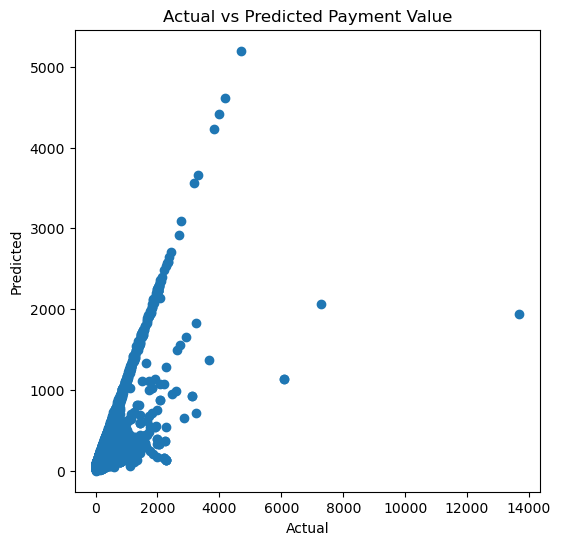

In [46]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted Payment Value")
plt.show()

## Xem hệ số của các biến 
### Xác định mức độ ảnh hưởng của từng feature đến kết quả dự đoán của mô hình.

In [47]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

coefficients.sort_values(by='Coefficient', ascending=False)

,Feature,Coefficient
10,year,6.207236e+00
1,freight_value,1.359517e+00
11,month,1.109813e+00
0,price,1.093383e+00
7,product_category_name,5.264360e-01
12,day,2.594352e-01
5,customer_city,1.662130e-03
2,order_status,-2.861600e-14
4,customer_unique_id,-3.079379e-05
9,product_id,-1.125140e-04


## Lưu model vào file pkl

In [48]:
import pickle


with open(r"D:\UNIVERSITY\ĐACN\BI-Dashboard-Project\models/linear_model.pkl", "wb") as f:
    pickle.dump(model, f)

In [49]:
import pickle

pickle.load(open(r"D:\UNIVERSITY\ĐACN\BI-Dashboard-Project\models/linear_model.pkl","rb"))

LinearRegression()